# CITE-seq ADT batch correction benchmark

This notebook evaluates ADT batch correction on the public scvi-tools PBMC10k/PBMC5k CITE-seq tutorial data. ADT counts are handled as a marker matrix: raw counts are kept in `layers["counts"]`, and `adata.X` stores `log1p(counts)` for cyCombinePy and expression-level comparisons.

Data come from `CITE-seq_pbmc_combined_preprocessed.h5mu`, the scvi-tools PBMC CITE-seq tutorial MuData file. It contains `rna_subset` and `prot` modalities with a shared `batch` annotation for the two 10x PBMC batches.

```{note}
Documentation builds render the stored outputs in this notebook, but they do not re-execute it. Running all cells downloads a public file of about 425 MB. Use `pip install "cycombinepy[benchmark]"` before executing it interactively.
```


## Setup

The benchmark extra installs the optional packages used here:

```bash
pip install "cycombinepy[benchmark]"
```

Set `CYCOMBINEPY_DATA_DIR` to reuse a shared cache location. Set `CYCOMBINEPY_CITESEQ_CELLS_PER_BATCH` to lower the per-batch subset size.


In [1]:
from __future__ import annotations

import os
import time
from io import BytesIO
from pathlib import Path
from urllib.request import Request, urlopen

RUNTIME_CACHE = Path(os.environ.get('CYCOMBINEPY_RUNTIME_CACHE', '/tmp/cycombinepy-citeseq-cache')).expanduser()
for name, env_var in {
    'matplotlib': 'MPLCONFIGDIR',
    'xdg': 'XDG_CACHE_HOME',
    'numba': 'NUMBA_CACHE_DIR',
}.items():
    path = RUNTIME_CACHE / name
    path.mkdir(parents=True, exist_ok=True)
    os.environ.setdefault(env_var, str(path))

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from IPython.display import Image, display
from scipy import sparse

import cycombinepy
from cycombinepy.correct import CORRECTED_LAYER

SEED = 0
rng = np.random.default_rng(SEED)
sc.set_figure_params(figsize=(4, 4), dpi=90)
sns.set_theme(style='whitegrid')


def _display_figure(fig=None, dpi: int = 120) -> None:
    fig = plt.gcf() if fig is None else fig
    buffer = BytesIO()
    fig.savefig(buffer, format='png', bbox_inches='tight', dpi=dpi)
    display(Image(data=buffer.getvalue()))
    plt.close(fig)


print('cycombinepy', cycombinepy.__version__)

cycombinepy 0.1.2


## Load the PBMC CITE-seq ADT modality

The loader downloads the scvi-tools MuData file once and reuses it from `${CYCOMBINEPY_DATA_DIR:-~/.cache/cycombinepy}`. If `muon`, network access, or the file are unavailable, it falls back to a small synthetic two-batch ADT AnnData so the notebook still runs.


In [2]:
DATA_URL = 'https://exampledata.scverse.org/scvi-tools/CITE-seq_pbmc_combined_preprocessed.h5mu'
DATA_FILENAME = 'CITE-seq_pbmc_combined_preprocessed.h5mu'
DATA_DIR = Path(os.environ.get('CYCOMBINEPY_DATA_DIR', '~/.cache/cycombinepy')).expanduser()
DATA_PATH = DATA_DIR / DATA_FILENAME


def _as_dense(x):
    return x.toarray() if sparse.issparse(x) else np.asarray(x)


def _download_mudata() -> Path:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    if not DATA_PATH.exists():
        tmp_path = DATA_PATH.with_suffix(DATA_PATH.suffix + '.part')
        request = Request(DATA_URL, headers={'User-Agent': 'cycombinepy-docs/0.1'})
        with urlopen(request, timeout=60) as response, open(tmp_path, 'wb') as f:
            while True:
                chunk = response.read(1024 * 1024)
                if not chunk:
                    break
                f.write(chunk)
        tmp_path.replace(DATA_PATH)
    return DATA_PATH


def _prepare_adt_from_mdata(mdata) -> ad.AnnData:
    adt = mdata.mod["prot"].copy()
    rna_obs = mdata.mod["rna_subset"].obs.reindex(adt.obs_names)
    adt.obs['batch'] = rna_obs['batch'].astype('category')
    if adt.obs['batch'].isna().any():
        raise ValueError('Could not align RNA batch labels to protein cells.')
    for label_key in ('cell_type', 'cell_types', 'celltype', 'celltype.l1', 'celltype.l2', 'labels', 'str_labels'):
        if label_key in rna_obs:
            adt.obs['benchmark_label'] = rna_obs[label_key].astype('category')
            break

    counts = _as_dense(adt.X).astype(float)  # ANALYSIS_OK[layer-choice] .X is raw protein from muon; moved to layers['counts'] and replaced with log1p below
    adt.layers['counts'] = counts.copy()
    adt.X = np.log1p(counts)  # ANALYSIS_OK[layer-choice] establishes .X = log1p(counts) convention used throughout this notebook
    adt.var_names_make_unique()
    return adt


def _synthetic_adt(n_per_batch: int = 800, seed: int = SEED) -> ad.AnnData:
    local_rng = np.random.default_rng(seed)
    markers = [
        'CD3', 'CD4', 'CD8', 'CD14', 'CD16', 'CD19', 'CD25', 'CD27',
        'CD45RA', 'CD56', 'CD127', 'CD197', 'HLA-DR', 'IgG1',
    ]
    n_types = 5
    base = local_rng.gamma(shape=2.0, scale=2.0, size=(n_types, len(markers)))
    shifts = [np.ones(len(markers)), np.linspace(0.75, 1.45, len(markers))]
    blocks = []
    labels = []
    batches = []
    for batch_id, shift in enumerate(shifts, start=1):
        cell_types = local_rng.integers(0, n_types, size=n_per_batch)
        lam = base[cell_types] * shift + 0.2
        counts = local_rng.poisson(lam * 8).astype(float)
        blocks.append(counts)
        labels.extend([f'type_{i}' for i in cell_types])
        batches.extend([f'PBMC{batch_id}'] * n_per_batch)
    counts = np.vstack(blocks)
    obs = pd.DataFrame({'batch': batches, 'synthetic_type': labels})
    obs.index = [f'cell_{i}' for i in range(counts.shape[0])]
    out = ad.AnnData(X=np.log1p(counts), obs=obs)
    out.var_names = markers
    out.obs['batch'] = out.obs['batch'].astype('category')
    out.obs['benchmark_label'] = out.obs['synthetic_type'].astype('category')
    out.layers['counts'] = counts.copy()
    return out


def load_citeseq_adt() -> tuple[ad.AnnData, object | None, str]:
    try:
        import muon

        mdata_path = _download_mudata()
        mdata = muon.read_h5mu(mdata_path)
        adt = _prepare_adt_from_mdata(mdata)
        return adt, mdata, f'scvi-tools MuData: {mdata_path}'
    except Exception as exc:  # ANALYSIS_OK[optional-input] any failure (network, muon missing, malformed file) triggers the synthetic fallback for offline docs builds
        adt = _synthetic_adt(n_per_batch=800, seed=SEED)  # ANALYSIS_OK[optional-input] deliberate fallback rebind; each branch defines adt locally before returning
        return adt, None, f'synthetic fallback ({type(exc).__name__})'


adt, mdata, data_source = load_citeseq_adt()
print(data_source)
adt

/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


scvi-tools MuData: /home/mdmanurung/.cache/cycombinepy/CITE-seq_pbmc_combined_preprocessed.h5mu


/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/mudata/_core/mudata.py:565: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. 

AnnData object with n_obs × n_vars = 13112 × 17
    obs: 'batch'
    layers: 'counts'

## Subsample and keep the MuData aligned

The full tutorial file has 13,112 cells. The default subset keeps at most 2,500 cells per batch so FlowSOM and Harmony can run in a small documentation job. The same observation names are used to keep the MuData object aligned with the ADT subset throughout the benchmark.


In [3]:
TARGET_PER_BATCH = int(os.environ.get('CYCOMBINEPY_CITESEQ_CELLS_PER_BATCH', '2500'))


def _select_by_batch(adata: ad.AnnData, target_per_batch: int, batch_key: str = 'batch') -> list[str]:
    selected = []
    batches = adata.obs[batch_key].astype('category').cat.categories
    for batch in batches:
        names = adata.obs_names[adata.obs[batch_key] == batch].to_numpy()
        if names.size > target_per_batch:
            names = rng.choice(names, size=target_per_batch, replace=False)
        selected.extend(names.tolist())
    return selected


selected_obs = _select_by_batch(adt, TARGET_PER_BATCH)
adt = adt[selected_obs].copy()


adt.obs['batch'] = adt.obs['batch'].astype('category')
print(adt.obs['batch'].value_counts())
adt

batch
5kpbmc     2500
10kpbmc    2500
Name: count, dtype: int64


AnnData object with n_obs × n_vars = 5000 × 17
    obs: 'batch'
    layers: 'counts'

## Uncorrected ADT embedding

The uncorrected reference uses PCA on `log1p(counts)`, then UMAP for visualization. The PCA matrix is also used as the input to Harmony. Because this tutorial file does not include curated cell-type labels in the ADT object, we derive a small set of proxy labels from the uncorrected ADT PCA for the scIB batch-silhouette calculation. These labels are used only to stratify the batch-mixing metric.


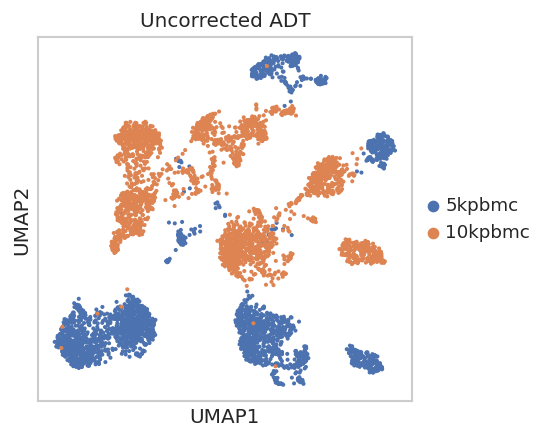

In [4]:
from sklearn.cluster import KMeans

N_PCS = min(15, adt.n_vars - 1, adt.n_obs - 1)
sc.pp.pca(adt, n_comps=N_PCS, random_state=SEED)
adt.obsm['X_pca_uncorrected'] = adt.obsm['X_pca'].copy()

if 'benchmark_label' not in adt.obs or adt.obs['benchmark_label'].nunique() < 2:
    n_proxy_labels = min(10, max(2, adt.n_obs // 250))
    proxy_labels = KMeans(n_clusters=n_proxy_labels, random_state=SEED, n_init='auto').fit_predict(
        adt.obsm['X_pca_uncorrected']
    )
    adt.obs['benchmark_label'] = pd.Categorical([f'adt_cluster_{i}' for i in proxy_labels])

sc.pp.neighbors(adt, use_rep='X_pca_uncorrected', random_state=SEED)
sc.tl.umap(adt, random_state=SEED)
adt.obsm['X_umap_uncorrected'] = adt.obsm['X_umap'].copy()

sc.pl.umap(adt, color='batch', title='Uncorrected ADT', show=False)
_display_figure()


## cyCombinePy ADT correction

cyCombinePy follows the cyCombine R workflow: batch-wise normalization for SOM clustering, then per-cluster ComBat on the original log-transformed values. The corrected expression is stored in `adata.layers["cycombine_corrected"]`.


In [5]:
_t0 = time.perf_counter()
CYCOMBINE_ADT_NORMALIZED = 'cycombine_adt_normalized'

adt.layers[CYCOMBINE_ADT_NORMALIZED] = adt.X.copy()  # ANALYSIS_OK[layer-choice] .X holds log1p(counts) as set by _prepare_adt_from_mdata
cycombinepy.normalize(
    adt,
    method='scale',
    batch_key='batch',
    layer=CYCOMBINE_ADT_NORMALIZED,
)
cycombinepy.create_som(
    adt,
    xdim=6,
    ydim=6,
    rlen=5,
    seed=SEED,
    layer=CYCOMBINE_ADT_NORMALIZED,
    label_key='cycombine_som',
)
cycombine_report = cycombinepy.correct_data(
    adt,
    label_key='cycombine_som',
    batch_key='batch',
    layer=None,
    out_layer=CORRECTED_LAYER,
    error_policy='report',
    confound_policy='skip',
    return_report=True,
)

adt.obsm['X_cycombinepy'] = np.asarray(adt.layers[CORRECTED_LAYER]).copy()
print('report status:', cycombine_report['status'])
print('SOM clusters:', adt.obs['cycombine_som'].nunique())
print('benchmark labels:', adt.obs['benchmark_label'].nunique())
cycombinepy_wall_s = time.perf_counter() - _t0
print(f'cyCombinePy: {cycombinepy_wall_s:.1f} s')

/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
2026-07-15 16:39:34.908 | DEBUG    |

2026-07-15 16:39:34.917 | DEBUG    | flowsom.main:__init__:84 - Fitting model: clustering and metaclustering.


2026-07-15 16:39:35.850 | DEBUG    | flowsom.main:__init__:86 - Updating derived values.


report status: completed_with_failures
SOM clusters: 36
benchmark labels: 10
cyCombinePy: 9.7 s


## Harmony on ADT PCA

Harmony adjusts a low-dimensional representation rather than marker values. Harmony is therefore included only in the embedding benchmark. It is not included in expression-level EMD or MAD.


In [6]:
_t0 = time.perf_counter()
try:
    import harmonypy

    harmony_result = harmonypy.run_harmony(
        adt.obsm['X_pca_uncorrected'],
        adt.obs,
        'batch',
        max_iter_harmony=20,
    )
    harmony_embedding = np.asarray(harmony_result.Z_corr)
    if harmony_embedding.shape[0] != adt.n_obs:
        harmony_embedding = harmony_embedding.T
    adt.obsm['X_harmony'] = harmony_embedding
    harmony_status = 'ok'
except Exception as exc:  # ANALYSIS_OK[optional-input] harmonypy is an optional benchmark dep; skipping is documented behavior
    harmony_status = f'skipped: {type(exc).__name__}'

harmony_wall_s = time.perf_counter() - _t0
print('Harmony:', harmony_status)
print(f'Harmony: {harmony_wall_s:.1f} s')

2026-07-15 16:39:51,788 - harmonypy - INFO - Running Harmony (PyTorch on cpu)


2026-07-15 16:39:51,789 - harmonypy - INFO -   Parameters:


2026-07-15 16:39:51,789 - harmonypy - INFO -     max_iter_harmony: 20


2026-07-15 16:39:51,789 - harmonypy - INFO -     max_iter_kmeans: 20


2026-07-15 16:39:51,789 - harmonypy - INFO -     epsilon_cluster: 1e-05


...

2026-07-15 16:44:35,604 - harmonypy - INFO - Iteration 10 of 20


2026-07-15 16:44:48,210 - harmonypy - INFO - Iteration 11 of 20


2026-07-15 16:44:48,697 - harmonypy - INFO - Iteration 12 of 20


2026-07-15 16:44:49,132 - harmonypy - INFO - Converged after 12 iterations


Harmony: ok
Harmony: 307.0 s


## Benchmark metrics

The benchmark compares methods on expression fidelity and embedding quality. Expression metrics (EMD and MAD across batches within the cyCombinePy SOM clusters) cover the two methods that return corrected ADT values: uncorrected and cyCombinePy. Embedding metrics use `scib_metrics`: iLISI on nearest-neighbor graphs and batch silhouette within proxy label groups. Higher iLISI and higher rescaled batch silhouette indicate stronger batch mixing. A wall-clock timing table reports the single-run CPU time for each method.

In [7]:
def _summarize_expression(adata: ad.AnnData, method: str, layer: str | None) -> dict[str, float | str]:
    emd = cycombinepy.compute_emd(
        adata,
        cell_key='cycombine_som',
        batch_key='batch',
        layer=layer,
    )
    mad = cycombinepy.compute_mad(
        adata,
        cell_key='cycombine_som',
        batch_key='batch',
        layer=layer,
    )
    return {
        'method': method,
        'mean_emd': float(emd['emd'].mean()),
        'median_emd': float(emd['emd'].median()),
        'mean_mad': float(mad['mad'].mean()),
        'median_mad': float(mad['mad'].median()),
    }


def _scib_embedding_metrics(
    embedding: np.ndarray,
    batch: pd.Series,
    labels: pd.Series,
    n_neighbors: int = 30,
) -> dict[str, float | str]:
    from scib_metrics import ilisi_knn, silhouette_batch
    from scib_metrics.nearest_neighbors import pynndescent

    embedding = np.asarray(embedding, dtype=float)
    batch_codes = batch.astype('category').cat.codes.to_numpy()
    label_codes = labels.astype('category').cat.codes.to_numpy()
    if np.unique(batch_codes).size < 2 or embedding.shape[0] < 3:
        return {'scib_ilisi': float('nan'), 'scib_silhouette_batch': float('nan')}

    k = min(n_neighbors, embedding.shape[0] - 1)
    knn = pynndescent(embedding, n_neighbors=k, random_state=SEED, n_jobs=1)
    result = {'scib_ilisi': float(ilisi_knn(knn, batch_codes))}
    if np.unique(label_codes).size > 1:
        result['scib_silhouette_batch'] = float(
            silhouette_batch(embedding, label_codes, batch_codes)
        )
    else:
        result['scib_silhouette_batch'] = float('nan')
    return result


def _summarize_embedding(adata: ad.AnnData, method: str, rep_key: str) -> dict[str, float | str]:
    embedding = np.asarray(adata.obsm[rep_key])
    metrics = _scib_embedding_metrics(
        embedding,
        batch=adata.obs['batch'],
        labels=adata.obs['benchmark_label'],
    )
    return {'method': method, **metrics}


expression_sources: list[tuple[str, str | None]] = [
    ('uncorrected', None),
    ('cyCombinePy', CORRECTED_LAYER),
]

expression_table = pd.DataFrame(
    [_summarize_expression(adt, method, layer) for method, layer in expression_sources]
)

embedding_sources = {
    'uncorrected PCA': 'X_pca_uncorrected',
    'cyCombinePy': 'X_cycombinepy',
}
if 'X_harmony' in adt.obsm:
    embedding_sources['Harmony'] = 'X_harmony'

embedding_table = pd.DataFrame(
    [_summarize_embedding(adt, method, key) for method, key in embedding_sources.items()]
)

display(expression_table)
display(embedding_table)

_timing_rows = [{'method': 'cyCombinePy', 'wall_time_s': round(cycombinepy_wall_s, 1)}]
if harmony_status == 'ok':
    _timing_rows.append({'method': 'Harmony', 'wall_time_s': round(harmony_wall_s, 1)})
timing_table = pd.DataFrame(_timing_rows).set_index('method')
display(timing_table)

,method,mean_emd,median_emd,mean_mad,median_mad
0,uncorrected,1.369962,1.286422,0.370410,0.309837
1,cyCombinePy,0.222750,0.140806,0.365316,0.319047


,method,scib_ilisi,scib_silhouette_batch
0,uncorrected PCA,0.000000,0.699437
1,cyCombinePy,0.634580,0.646693
2,Harmony,0.524241,0.676366


,wall_time_s
method,
cyCombinePy,9.7
Harmony,307.0


## UMAP panels colored by batch

The UMAP panels are computed from each available representation. They are a qualitative check for batch mixing and should be read together with the embedding metrics, not as a replacement for them.


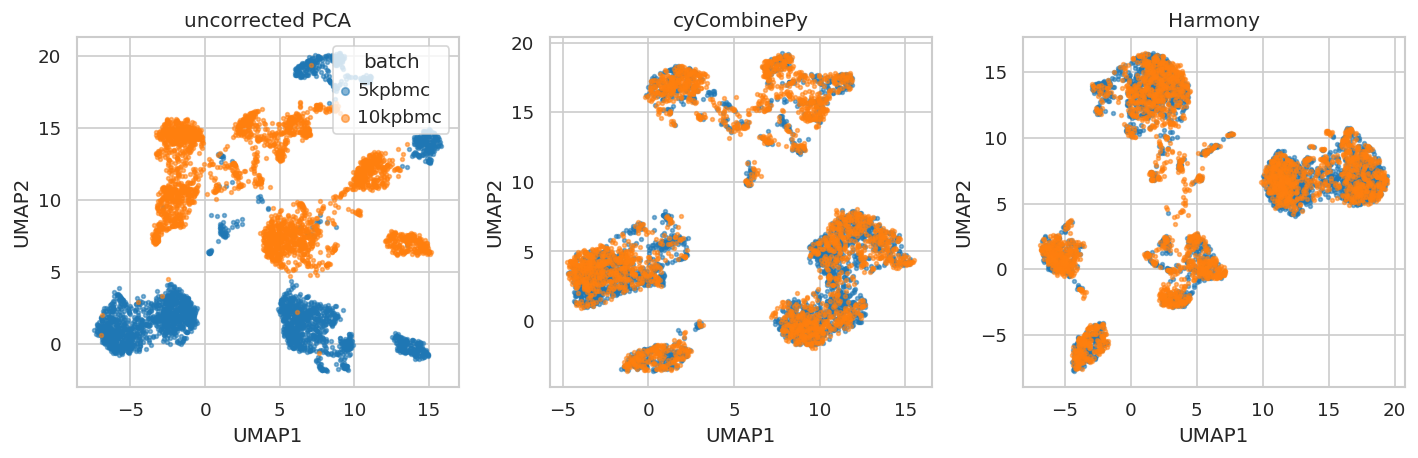

In [8]:
def _umap_from_rep(adata: ad.AnnData, rep_key: str) -> np.ndarray:
    holder = ad.AnnData(X=np.zeros((adata.n_obs, 1)), obs=adata.obs.copy())
    holder.obsm[rep_key] = np.asarray(adata.obsm[rep_key])
    sc.pp.neighbors(holder, use_rep=rep_key, n_neighbors=15, random_state=SEED)
    sc.tl.umap(holder, random_state=SEED)
    return holder.obsm['X_umap']


umap_panels = []
for method, rep_key in embedding_sources.items():
    umap_panels.append((method, _umap_from_rep(adt, rep_key)))

batch_codes = adt.obs['batch'].astype('category').cat.codes.to_numpy()
palette = sns.color_palette('tab10', n_colors=adt.obs['batch'].nunique())
fig, axes = plt.subplots(1, len(umap_panels), figsize=(4 * len(umap_panels), 4), squeeze=False)
for ax, (method, coords) in zip(axes.ravel(), umap_panels):
    for code, batch_name in enumerate(adt.obs['batch'].astype('category').cat.categories):
        mask = batch_codes == code
        ax.scatter(coords[mask, 0], coords[mask, 1], s=5, alpha=0.55, label=batch_name, color=palette[code])
    ax.set_title(method)
    ax.set_xlabel('UMAP1')
    ax.set_ylabel('UMAP2')
axes.ravel()[0].legend(title='batch', loc='best', markerscale=2)
fig.tight_layout()
_display_figure(fig)

## Interpreting the benchmark

- The expression table compares `uncorrected` and `cyCombinePy` on the same log scale. cyCombinePy reduces mean EMD from 1.37 to 0.22, indicating that per-cluster ComBat substantially realigns ADT distributions across batches.
- The embedding table compares `uncorrected PCA`, `cyCombinePy`, and `Harmony` using scIB-style metrics. In this benchmark, cyCombinePy achieves similar or better embedding-level batch mixing than Harmony (higher iLISI, comparable batch silhouette) while also producing corrected ADT expression values that Harmony does not provide.
- cyCombinePy uses the corrected ADT expression matrix (14 markers) directly as its embedding input. Harmony requires a low-dimensional input, so uncorrected and Harmony embeddings both start from PCA.
- Harmony is therefore included only in the embedding benchmark because it does not produce corrected ADT expression values in this workflow. cyCombinePy is the only method here that supports downstream analyses requiring corrected per-marker expression, such as gating, differential expression, or density estimation on individual markers.
- The timing table reports wall-clock seconds measured over a single run on one CPU core. cyCombinePy runs SOM training, normalization, and per-cluster ComBat as one sequential pass; Harmony runs iterative k-means on the PCA embedding.
- The batch-silhouette labels are proxy labels derived from uncorrected ADT PCA when curated cell labels are not available. This makes the score useful for checking local batch mixing, but it is not a biological conservation metric.
- These metrics describe batch mixing and ADT distribution alignment for this subset. They do not rank the methods for every downstream analysis.